In [3]:
import pandas as pd
df = pd.read_csv('nifty.csv')
print(df.head())

         Date      Open      High       Low     Close   Shares Traded   \
0  15-MAY-2026  23731.40  23839.30  23610.30  23643.50       408864566   
1  14-MAY-2026  23530.25  23777.20  23426.55  23689.60       428735424   
2  13-MAY-2026  23362.45  23582.95  23262.55  23412.60       415359044   
3  12-MAY-2026  23722.60  23757.55  23348.40  23379.55       447518189   
4  11-MAY-2026  23970.10  23997.45  23799.10  23815.85       390108343   

   Turnover (₹ Cr)  
0         35052.32  
1         38828.33  
2         33693.48  
3         36200.59  
4         37404.28  


In [6]:
# 1. First, forcefully clean all trailing spaces out of the column headers again
df.columns = df.columns.str.strip()

# 2. Now run the predictive feature engineering safely
df['Tomorrow_Close'] = df['Close'].shift(-1)

# Target: 1 if tomorrow's close is higher than today's close, else 0
df['Target'] = (df['Tomorrow_Close'] > df['Close']).astype(int)

# Select your features
features = ['Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover (₹ Cr)']

# Drop the very last row because we don't know tomorrow's outcome yet
df_ml = df.dropna().copy()

X = df_ml[features]
y = df_ml['Target']

print("Success! Features and target variables are successfully locked in.")

Success! Features and target variables are successfully locked in.


In [8]:
from sklearn.model_selection import train_test_split

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("Data successfully split into training and testing sets!")

Data successfully split into training and testing sets!


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on your training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)
y_colors = model.predict_proba(X_test)[:, 1] # Probability scores for ROC Curve

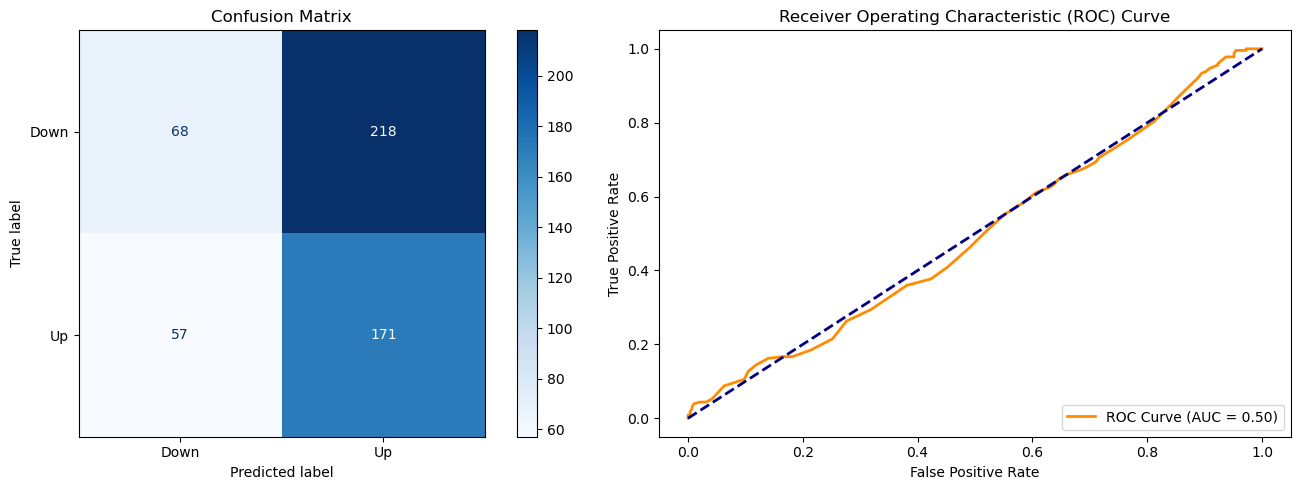

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# 2. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_colors)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_12080\2862233226.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ml['Date'] = pd.to_datetime(df_ml['Date'])


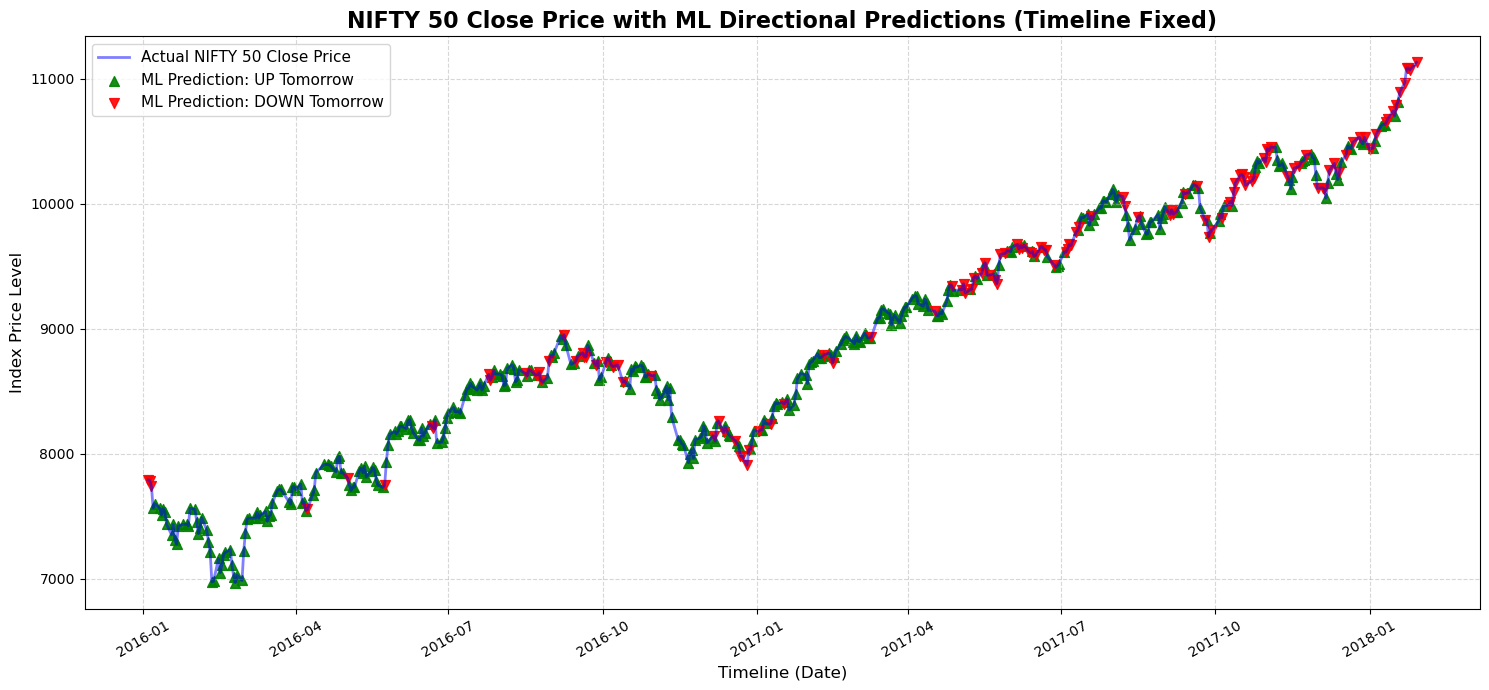

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure the dates in our ML dataframe are explicitly in datetime format
df_ml['Date'] = pd.to_datetime(df_ml['Date'])

# 2. Extract the exact matching slice for our test sets directly by position
test_df = df_ml.iloc[-len(y_pred):].copy()

# 3. Set up the plotting canvas
plt.figure(figsize=(15, 7))

# Plot the continuous actual timeline string
plt.plot(test_df['Date'], test_df['Close'], label='Actual NIFTY 50 Close Price', color='blue', alpha=0.5, linewidth=2)

# 4. Map the predictions safely using numpy arrays matching the exact length
up_mask = (y_pred == 1)
down_mask = (y_pred == 0)

# Overlay the UP predictions
plt.scatter(test_df['Date'].values[up_mask], test_df['Close'].values[up_mask], 
            color='green', label='ML Prediction: UP Tomorrow', marker='^', alpha=0.9, s=50)

# Overlay the DOWN predictions
plt.scatter(test_df['Date'].values[down_mask], test_df['Close'].values[down_mask], 
            color='red', label='ML Prediction: DOWN Tomorrow', marker='v', alpha=0.9, s=50)

# 5. Format layout and force explicit date formatting on the timeline axis
plt.title('NIFTY 50 Close Price with ML Directional Predictions (Timeline Fixed)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Date)', fontsize=12)
plt.ylabel('Index Price Level', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# Rotate dates for neat spacing
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

df_ml['Date'] = pd.to_datetime(df_ml['Date'])
df_sorted = df_ml.sort_values('Date').reset_index(drop=True)

start_date = df_sorted['Date'].min()
df_sorted['Days_Elapsed'] = (df_sorted['Date'] - start_date).dt.days

X_trend = df_sorted[['Days_Elapsed']]
y_trend = df_sorted['Close']

# Fit a Polynomial Regression model to capture the structural market curve
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_trend)

model_5yr = LinearRegression()
model_5yr.fit(X_poly, y_trend)

# Generate a Future Timeline 5 Years out (From 2026 out to mid-2031)
last_day = df_sorted['Days_Elapsed'].max()
future_days = np.arange(last_day, last_day + (5 * 365)).reshape(-1, 1)
future_poly = poly.transform(future_days)

# Generate future date objects for the plot
future_dates = pd.date_range(start=df_sorted['Date'].max(), periods=5*365, freq='D')
future_predictions = model_5yr.predict(future_poly)

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


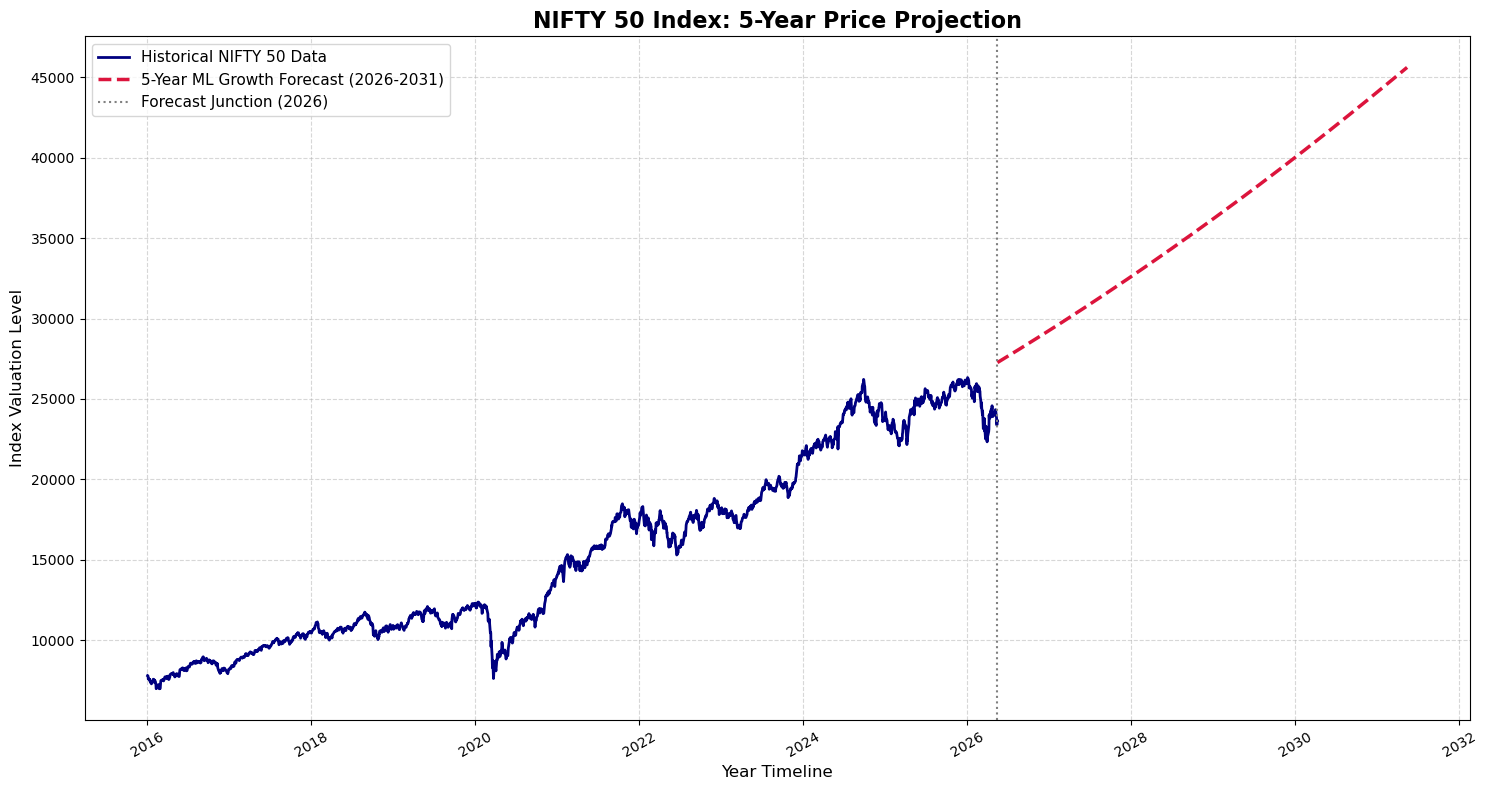

In [17]:
plt.figure(figsize=(15, 8))

# Plot historical actuals
plt.plot(df_sorted['Date'], df_sorted['Close'], label='Historical NIFTY 50 Data', color='Navy', linewidth=2)

# Plot the 5-year forecast trend line
plt.plot(future_dates, future_predictions, label='5-Year ML Growth Forecast (2026-2031)', 
         color='Crimson', linestyle='--', linewidth=2.5)

# Visual design flourishes
plt.title('NIFTY 50 Index: 5-Year Price Projection', fontsize=16, fontweight='bold')
plt.xlabel('Year Timeline', fontsize=12)
plt.ylabel('Index Valuation Level', fontsize=12)
plt.axvline(x=df_sorted['Date'].max(), color='gray', linestyle=':', label='Forecast Junction (2026)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()